<a href="https://colab.research.google.com/github/mgarbanzo/GOES16/blob/main/Generaci%C3%B3n_de_RGB_en_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

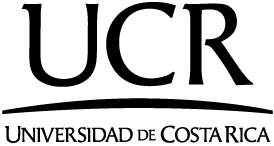

Profesor: Dr. Marcial Garbanzo Salas

Curso: 4201 - Introducción a Instrumentos Meteorológicos

Ciclo: II-2025

Objetivos de aprendizaje: Comprender el funcionamiento de los datos satelitales en diferentes colores del espectro y cómo se utiliza para generar imágenes completas en RGB y obtener más información de los mismos productos.

Updated on: Nov 21st 2025 to use GOES-19 data.

In [3]:
import numpy as np
import pylab as plt

# Se define una matriz de $(4x4)$ $x3$ de profundidad

Las capas de profundidad son las que definen el tono final al graficar.

Los valores por cada capa deben estar normalizados entre 0 y 1 para generar el color final, donde 0 es ninguna componente y 1 sería toda la componente de un color.

Una matriz de ceros debe entonces ser de color negro:

In [4]:
COLORES = np.zeros((4,4,3))

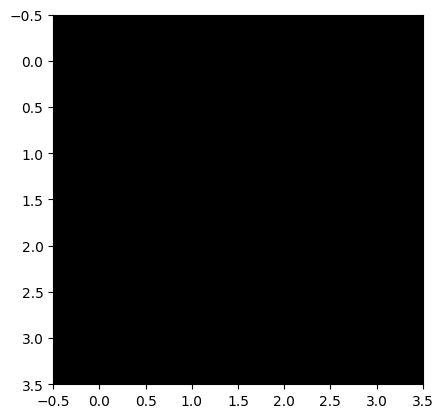

In [5]:
plt.figure()
plt.imshow(COLORES)

Si la primera capa (nivel 0 en Python) de la matriz COLORES se establece como 1, entonces el color ROJO representado por esa capa será total y no tendrá ningún otro color, ya que la capa 1 y 2 siguen teniendo valores de 0.

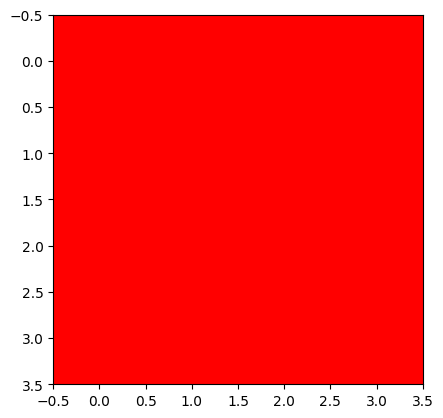

In [6]:
COLORES = np.zeros((4,4,3))
COLORES[:,:,0]=1
plt.figure()
plt.imshow(COLORES)

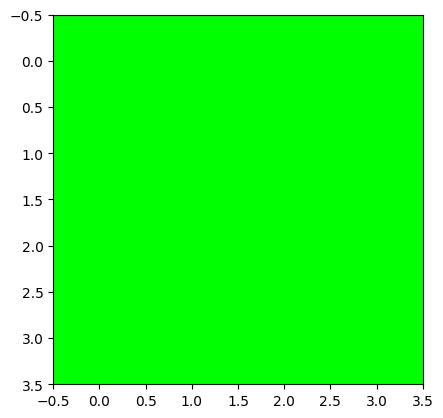

In [7]:
COLORES = np.zeros((4,4,3))
COLORES[:,:,1]=1
plt.figure()
plt.imshow(COLORES)

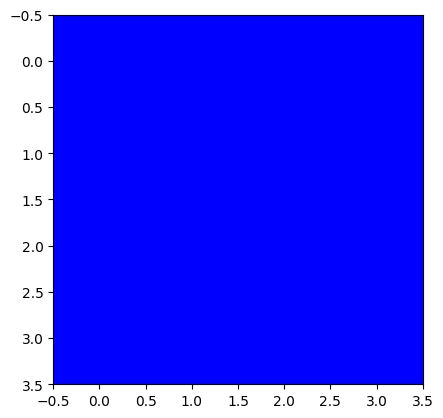

In [8]:
COLORES = np.zeros((4,4,3))
COLORES[:,:,2]=1
plt.figure()
plt.imshow(COLORES)

# Se pueden combinar diferentes valores en las capas para generar diferentes colores:

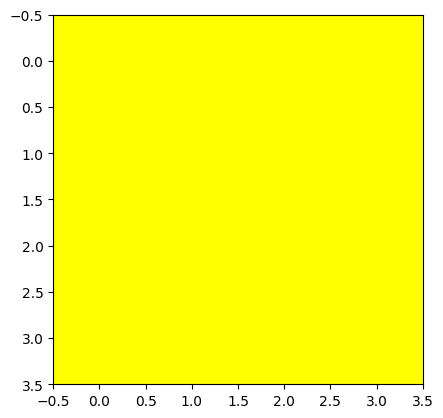

In [9]:
COLORES = np.zeros((4,4,3))
COLORES[:,:,0]=1
COLORES[:,:,1]=1
COLORES[:,:,2]=0
plt.figure()
plt.imshow(COLORES)

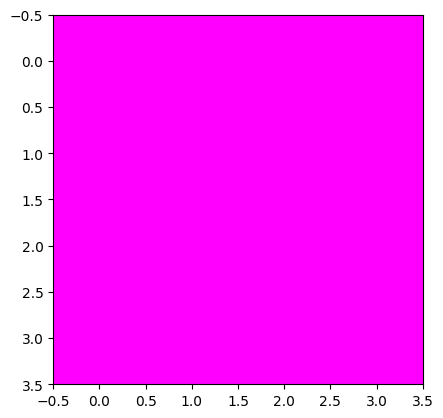

In [10]:
COLORES = np.zeros((4,4,3))
COLORES[:,:,0]=1
COLORES[:,:,1]=0
COLORES[:,:,2]=1
plt.figure()
plt.imshow(COLORES)

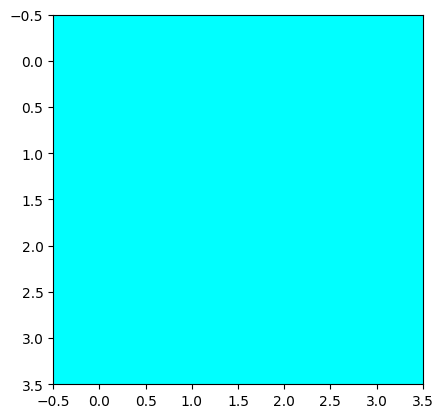

In [11]:
COLORES = np.zeros((4,4,3))
COLORES[:,:,0]=0
COLORES[:,:,1]=1
COLORES[:,:,2]=1
plt.figure()
plt.imshow(COLORES)

# Todas las capas con valores de 1 signigicaría que la matriz tiene cada punto con todo el rojo, todo el verde y todo el azul.

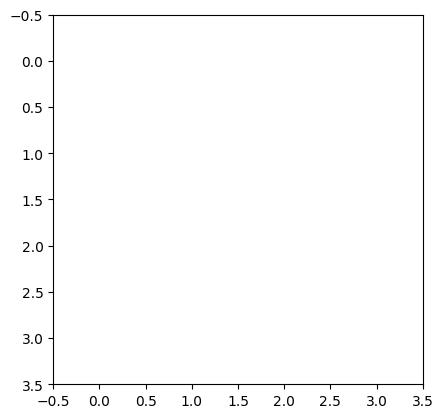

In [12]:
COLORES = np.zeros((4,4,3))
COLORES[:,:,0]=1
COLORES[:,:,1]=1
COLORES[:,:,2]=1
plt.figure()
plt.imshow(COLORES)

# Los colores se pueden establecer de manera individual.

**Es en este punto donde las mediciones satelitales permiten asignar a cada punto de una imagen el valor correspondiente observado por los sensores.**

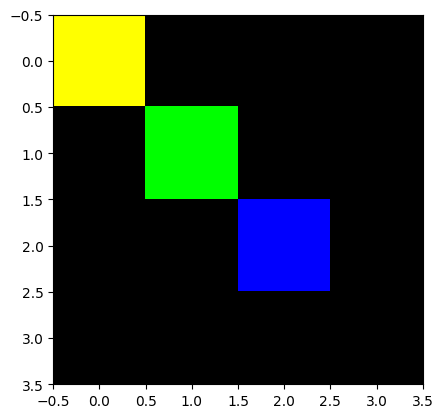

In [13]:
COLORES = np.zeros((4,4,3))
COLORES[1,1,1]=1
COLORES[0,0,0]=1
COLORES[0,0,1]=1
COLORES[2,2,2]=1
plt.figure()
plt.imshow(COLORES)

# Haciendo un RGB simple con datos del GOES 16

In [14]:
pip install netcdf4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.3 MB/s eta 0:00:00


In [15]:
!wget -c https://noaa-goes19.s3.amazonaws.com/ABI-L2-CMIPF/2025/325/18/OR_ABI-L2-CMIPF-M6C01_G19_s20253251800212_e20253251809520_c20253251809577.nc
!wget -c https://noaa-goes19.s3.amazonaws.com/ABI-L2-CMIPF/2025/325/18/OR_ABI-L2-CMIPF-M6C02_G19_s20253251800212_e20253251809520_c20253251809570.nc
!wget -c https://noaa-goes19.s3.amazonaws.com/ABI-L2-CMIPF/2025/325/18/OR_ABI-L2-CMIPF-M6C03_G19_s20253251800212_e20253251809520_c20253251809580.nc

--2025-11-21 20:34:42--  https://noaa-goes19.s3.amazonaws.com/ABI-L2-CMIPF/2025/325/18/OR_ABI-L2-CMIPF-M6C01_G19_s20253251800212_e20253251809520_c20253251809577.nc
Resolving noaa-goes19.s3.amazonaws.com (noaa-goes19.s3.amazonaws.com)... 16.182.96.121, 52.217.86.172, 16.15.192.14, ...
Connecting to noaa-goes19.s3.amazonaws.com (noaa-goes19.s3.amazonaws.com)|16.182.96.121|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 90077848 (86M) [binary/octet-stream]
Saving to: ‘OR_ABI-L2-CMIPF-M6C01_G19_s20253251800212_e20253251809520_c20253251809577.nc’

OR_ABI-L2-CMIPF-M6C 100%[===================>]  85.90M  18.2MB/s    in 5.9s    

2025-11-21 20:34:48 (14.6 MB/s) - ‘OR_ABI-L2-CMIPF-M6C01_G19_s20253251800212_e20253251809520_c20253251809577.nc’ saved [90077848/90077848]

--2025-11-21 20:34:48--  https://noaa-goes19.s3.amazonaws.com/ABI-L2-CMIPF/2025/325/18/OR_ABI-L2-CMIPF-M6C02_G19_s20253251800212_e20253251809520_c20253251809570.nc
Resolving noaa-goes19.s3.amazonaws.com (

In [16]:
from netCDF4 import Dataset
C1 = Dataset('/content/OR_ABI-L2-CMIPF-M6C01_G19_s20253251800212_e20253251809520_c20253251809577.nc')
C2 = Dataset('/content/OR_ABI-L2-CMIPF-M6C02_G19_s20253251800212_e20253251809520_c20253251809570.nc')
C3 = Dataset('/content/OR_ABI-L2-CMIPF-M6C03_G19_s20253251800212_e20253251809520_c20253251809580.nc')

In [17]:
ROJO = C2.variables['CMI'][:][::8,::8]
VERDE = C3.variables['CMI'][::4,::4]
AZUL = C1.variables['CMI'][::4,::4]

In [18]:
np.max(ROJO)

np.float32(1.1888877)

In [19]:
np.shape(ROJO), np.shape(VERDE), np.shape(AZUL)

((2712, 2712), (2712, 2712), (2712, 2712))

In [20]:
ROJO = (ROJO - ROJO.min()) / (ROJO.max() - ROJO.min())
VERDE = (VERDE - VERDE.min()) / (VERDE.max() - VERDE.min())
AZUL = (AZUL - AZUL.min()) / (AZUL.max() - AZUL.min())

In [21]:
COLORES = np.zeros((2712,2712,3))

In [22]:
COLORES[:,:,0] = ROJO
COLORES[:,:,1] = VERDE
COLORES[:,:,2] = AZUL

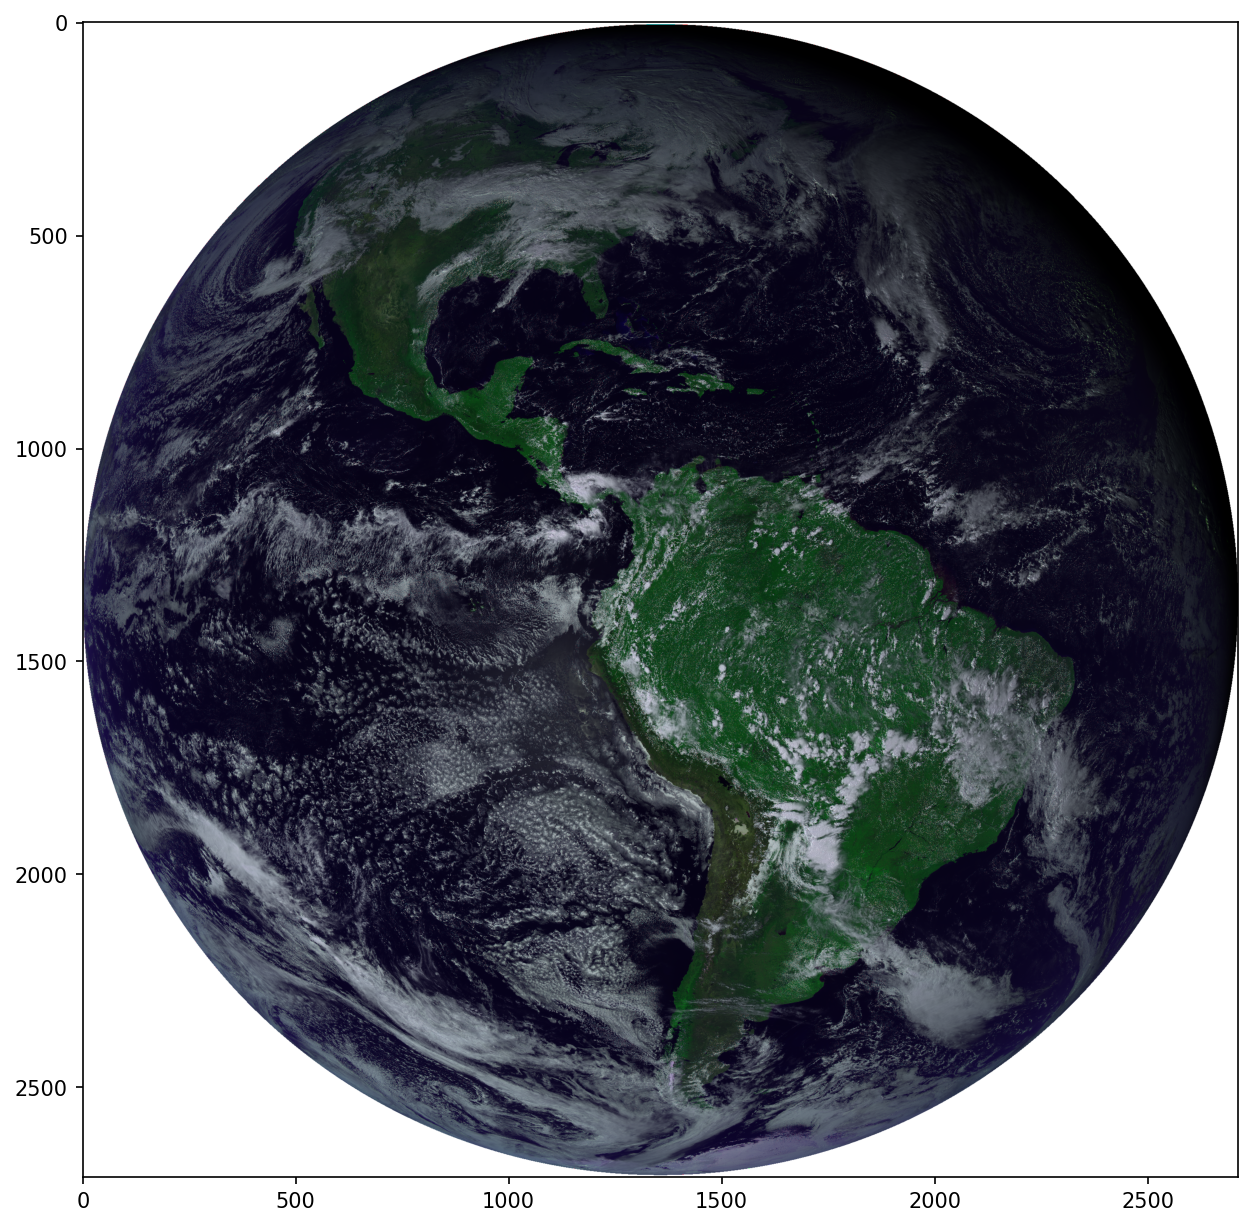

In [23]:
plt.figure(figsize = (10,10),dpi=150)
plt.imshow(COLORES)